In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("exoplanet_data.csv", comment="#")
df

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,7 CMa c,7 CMa,0,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2024-09-13,2024-07,2024-09-13
1,7 CMa c,7 CMa,1,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2019-10-18,2019-11,2019-10-24
2,DMPP-1 b,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05
3,DMPP-1 b,DMPP-1,0,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
4,DMPP-1 c,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,bet Pic c,bet Pic,0,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2025-09-25,2020-10,2025-09-25
579,bet Pic c,bet Pic,1,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2023-06-12,2022-09,2023-06-12
580,bet Pic c,bet Pic,0,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2019-08-23,2019-08,2019-08-29
581,eps Ind A b,eps Ind A,1,3,1,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,2.237,0.240,-0.240,4.34562,0.007374,-0.007374,2024-08-07,2024-09,2024-08-07


In [4]:
print("Shape: ", df.shape)
print("rows: ", df.shape[0])
print("cols: ", df.shape[1])

print("All column titles: ", df.columns.tolist())
# columns idk
unknown_cols = ['pl_orbsmax', 'pl_orbeccen', 'sy_snum', 'disc_facility', 'pl_orbincl']
print(unknown_cols)

Shape:  (583, 92)
rows:  583
cols:  92
All column titles:  ['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1

In [5]:
#4.3: reducing data
# Table Label: Planet Name
# Database Column Name: pl_name
# Description: Planet name most commonly used in the literature.
# In my own words: this is the main name of the exoplanet.

# Table Label: Host Name
# Database Column Name: hostname
# Description: Stellar name most commonly used in the literature.
# In my own words: this is the name of the star that the planet orbits.

# Table Label: Discovery Method
# Database Column Name: discoverymethod
# Description: Method by which the planet was first identified.
# In my own words: this tells how astronomers found the planet.

# Table Label: Spectral Type
# Database Column Name: st_spectype
# Description: Classification of the star based on their spectral characteristics following the Morgan-Keenan system.
# In my own words: this tells what kind of star it is, like G-type, K-type, etc.

# Table Label: Equilibrium Temperature [K]
# Database Column Name: pl_eqt
# Description: The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body.
# In my own words: this is an estimate of how hot the planet is.

# Table Label: Planet Mass or Mass*sin(i) [Jupiter Mass]
# Database Column Name: pl_bmassj
# Description: Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Jupiter masses.
# In my own words: this is the best available estimate of the planet’s mass, measured relative to Jupiter.

small_df = df[[
    "pl_name",
    "hostname",
    "discoverymethod",
    "st_spectype",
    "pl_eqt",
    "pl_bmassj"
]]

small_df = small_df.dropna()
small_df

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
3,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
5,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
7,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
8,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
10,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000
...,...,...,...,...,...,...
561,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980000
565,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000000
569,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300000
572,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709000


In [7]:
#4.3 step 6
print("shape of smaller dataset:", small_df.shape)
print("rows:", small_df.shape[0])
print("cols:", small_df.shape[1])

print("First five rows: ", small_df.head())

print("Last five rows:", small_df.tail())

print("Column titles:", small_df.columns.tolist())

shape of smaller dataset: (70, 6)
rows: 70
cols: 6
First five rows:       pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3   DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5   DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7   DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8   DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
Last five rows:          pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
561   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
565   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
569   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
572       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
Column titles: ['pl_name', 'hostname', 

In [8]:
#4.4
method_counts = small_df["discoverymethod"].value_counts()

print("Discovery methods and counts:")
print(method_counts)

print("Different discovery methods:", method_counts.index.tolist())

print("Method with the most:", method_counts.idxmax(), "-", method_counts.max())

print("Method with the least:", method_counts.idxmin(), "-", method_counts.min())

#discovery method explanations
#transit: astronomers detect a planet when it passes in front of its star and blocks a bit of light
#radial velocity: astronomers detect a planet by seeing the star wobble due to planet's gavity
#imaging: astronomers directly capture light from the planet

Discovery methods and counts:
discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64
Different discovery methods: ['Transit', 'Radial Velocity', 'Imaging']
Method with the most: Transit - 55
Method with the least: Imaging - 2


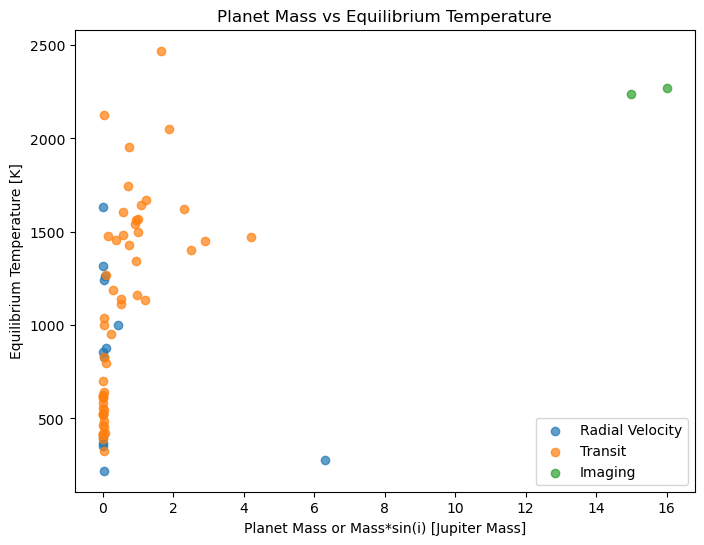

In [9]:
#4.4.2
plt.figure(figsize=(8, 6))

for method in small_df["discoverymethod"].unique():
    subset = small_df[small_df["discoverymethod"] == method]
    plt.scatter(
        subset["pl_bmassj"],
        subset["pl_eqt"],
        label=method,
        alpha=0.7
    )

plt.title("Planet Mass vs Equilibrium Temperature")
plt.xlabel("Planet Mass or Mass*sin(i) [Jupiter Mass]")
plt.ylabel("Equilibrium Temperature [K]")
plt.legend()
plt.show()

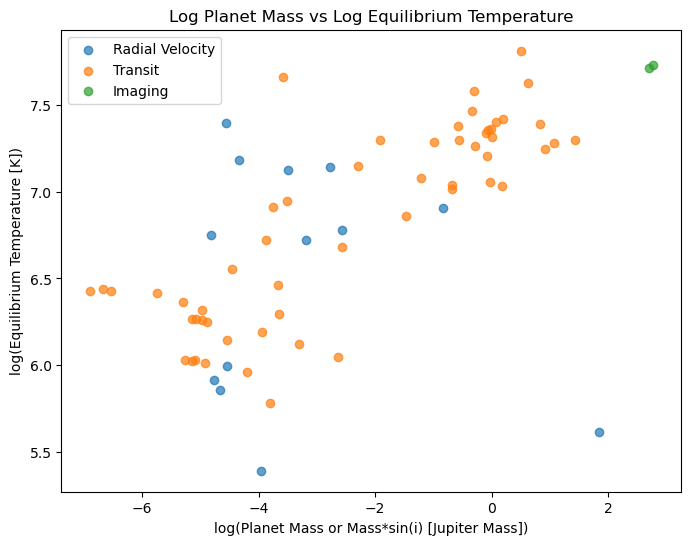

In [11]:
#4.4.3
log_df = small_df[(small_df["pl_bmassj"] > 0) & (small_df["pl_eqt"] > 0)]

plt.figure(figsize=(8, 6))

for method in log_df["discoverymethod"].unique():
    subset = log_df[log_df["discoverymethod"] == method]
    plt.scatter(
        np.log(subset["pl_bmassj"]),
        np.log(subset["pl_eqt"]),
        label=method,
        alpha=0.7
    )

plt.title("Log Planet Mass vs Log Equilibrium Temperature")
plt.xlabel("log(Planet Mass or Mass*sin(i) [Jupiter Mass])")
plt.ylabel("log(Equilibrium Temperature [K])")
plt.legend()
plt.show()

#4.4.4
#Based on the plot, exoplanets found by the imaging method appear more likely to be 
#massive rather than small, since the imaging points are concentrated at higher planet 
#masses.


In [13]:
#4.4.5: coldest
big_planets = small_df[small_df["pl_bmassj"] > 5]
coldest_planet = big_planets.loc[big_planets["pl_eqt"].idxmin()]
print(coldest_planet)

#4.4.6
print("Entire row for the coldest planet with mass > 5 Jupiter masses:")
print(coldest_planet)

print("Name:", coldest_planet["pl_name"])
print("Equilibrium temperature [K]:", coldest_planet["pl_eqt"])
print("Mass [Jupiter masses]:", coldest_planet["pl_bmassj"])
print("Spectral type of host star:", coldest_planet["st_spectype"])
coldest_index = big_planets["pl_eqt"].idxmin()
print("Index:", coldest_index)

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object
Entire row for the coldest planet with mass > 5 Jupiter masses:
pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object
Name: eps Ind A b
Equilibrium temperature [K]: 275.0
Mass [Jupiter masses]: 6.31
Spectral type of host star: K5 V
Index: 581


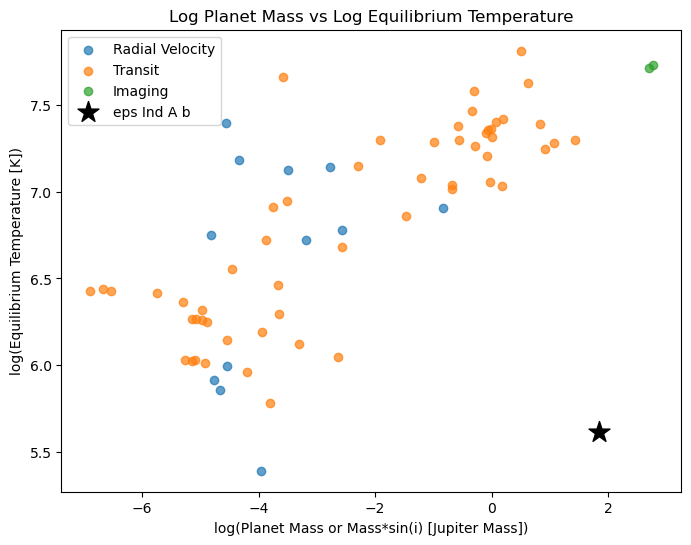

In [14]:
plt.figure(figsize=(8, 6))

for method in log_df["discoverymethod"].unique():
    subset = log_df[log_df["discoverymethod"] == method]
    plt.scatter(
        np.log(subset["pl_bmassj"]),
        np.log(subset["pl_eqt"]),
        label=method,
        alpha=0.7
    )

# highlight coldest planet
plt.scatter(
    np.log(coldest_planet["pl_bmassj"]),
    np.log(coldest_planet["pl_eqt"]),
    color="black",
    marker="*",
    s=250,
    label=coldest_planet["pl_name"]
)

plt.title("Log Planet Mass vs Log Equilibrium Temperature")
plt.xlabel("log(Planet Mass or Mass*sin(i) [Jupiter Mass])")
plt.ylabel("log(Equilibrium Temperature [K])")
plt.legend()
plt.show()

In [ ]:
#4.5
#name of article: A temperate super-Jupiter imaged with JWST in the mid-infrared
#summarize: paper reports direct imaging of a giant exoplanet using jwst
#    planet is unusual bc it is older and cooler than most directly imaged exoplanets
#    may have unusual atmospheric chemistry, possiblt involving high metallicity and high carbon to oxygen ratio
#does ur answer match the exoplanet? yes?

#this homework took FOREVER :o